<a href="https://colab.research.google.com/github/Jihad-chaalan/AIxMed/blob/main/SVM_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIxMed26 — Session 1 Assignment
## SVM on the Pima Indians Diabetes Dataset

---

### Dataset Description

The **Pima Indians Diabetes Dataset** comes from the National Institute of Diabetes. Each row represents a female patient.

| Feature | Description |
|---------|-------------|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skinfold thickness (mm) |
| Insulin | 2-Hour serum insulin |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes history score in relatives |
| Age | Age in years |
| **Outcome** | **0 = No Diabetes, 1 = Has Diabetes** |

Follow the same ML cycle from the lecture. Do **not** use the test set until Step 7.

---
## Step 0 — Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Step 1 — Define the Problem

In your own words answer the following:
- What is the medical question we are trying to answer?
- What are the inputs (X) and the output (y)?
- What type of ML task is this?

Medical Question:

Can we predict whether a female patient has diabetes based on her health indicators?

ML Setup:

Input (X): 8 numerical measurements features (Pregnancies, glucose, bloodpressure etc.)
Output (y): 0 = no diabetes — 1 = diabetes
Task type: Binary classification

---
## Step 2 — Load the Data

Load the dataset using the URL below, display its shape and class counts.

```
https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
```

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")

print(f"Dataset shape: {df.shape}")
print(f"  Rows (patients) : {df.shape[0]}")
print(f"  Columns (feat.) : {df.shape[1] - 1}  + 1 label column")
print()
print("Class counts:")
print(df['Outcome'].value_counts().rename({0: 'No Diabetes (0)', 1: 'Has Diabetes (1)'}))

Dataset shape: (768, 9)
  Rows (patients) : 768
  Columns (feat.) : 8  + 1 label column

Class counts:
Outcome
No Diabetes (0)     500
Has Diabetes (1)    268
Name: count, dtype: int64


---
## Step 3 — Explore the Data

### 3.1 Show the DataFrame

In [3]:
df.head(8)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


### 3.2 Compare Feature Values: No Diabetes vs Has Diabetes

Plot histograms for all 8 features separated by class.

**Hint:** Use `plt.subplot` in a loop like in the lecture.

In [4]:
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure',	'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
label_column = 'Outcome'

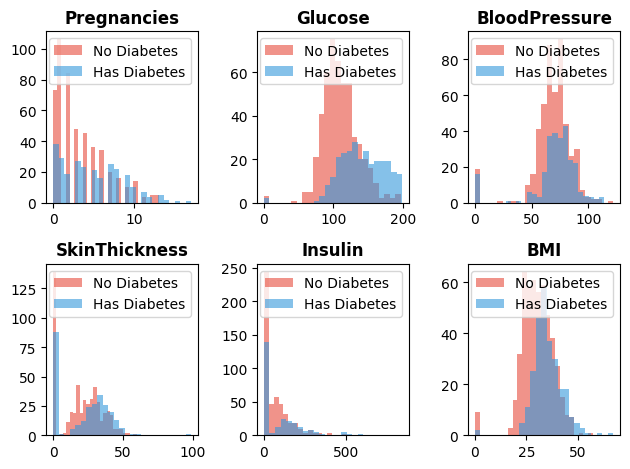

In [5]:
for i, feat in enumerate(feature_columns[:6]):
    plt.subplot(2, 3, i + 1)

    no_diabetes = df[df['Outcome'] == 0][feat]
    has_diabetes = df[df['Outcome'] == 1][feat]

    plt.hist(no_diabetes, bins=25, alpha=0.6, color='#e74c3c', label='No Diabetes')
    plt.hist(has_diabetes, bins=25, alpha=0.6, color='#3498db', label='Has Diabetes')
    plt.title(feat, fontweight='bold')
    plt.legend()

plt.tight_layout()
plt.show()

### 3.2 Observations

Which features look most different between the two classes? Write 2–3 sentences.

*Write your observations here.*

---
## Step 4 — Preprocess the Data

### 4.1 Separate Features and Label

Create `X` (all feature columns) and `y` (the `Outcome` column). Print their shapes.

In [6]:
X = df[feature_columns].values
y = df[label_column].values

print(f"X shape: {X.shape}  (samples × features)")
print(f"y shape: {y.shape}  (one label per sample)")

X shape: (768, 8)  (samples × features)
y shape: (768,)  (one label per sample)


### 4.2 Split into Train / Validation / Test

Use a **60 / 20 / 20** split with `random_state=42` and `stratify=y`. Print the size of each split.

In [7]:
# First: set aside the test set (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second: split the rest into train (75%) and validation (25%)
# 25% of 80% = 20% of total  →  final split: 60 / 20 / 20
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train      : {len(X_train)} samples  (60%)")
print(f"Validation : {len(X_val)} samples  (20%)")
print(f"Test       : {len(X_test)} samples  (20%)")
print(f"Total      : {len(X)} samples")

Train      : 460 samples  (60%)
Validation : 154 samples  (20%)
Test       : 154 samples  (20%)
Total      : 768 samples


### 4.3 Scale the Features

Apply `StandardScaler`. Fit on **train only**, then transform all three splits.

In [8]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling done.")
print(f"  Mean of first feature after scaling: {X_train_s[:, 0].mean():.4f}  (should be ~0)")
print(f"  Std  of first feature after scaling: {X_train_s[:, 0].std():.4f}   (should be ~1)")

Scaling done.
  Mean of first feature after scaling: 0.0000  (should be ~0)
  Std  of first feature after scaling: 1.0000   (should be ~1)


---
## Step 5 — Train the SVM

Train three SVM models using `C = [0.1, 1, 10]`. For each, print the validation accuracy. At the end, print the best C value.

In [27]:
# Try three values of C
c_values = [0.1, 1, 10, 0.9]

print("Training SVM with different C values...\n")
print(f"{'C':>6}  {'Val Accuracy':>14}")
print("-" * 25)

results = {}
for c in c_values:
    model = SVC(C=c, random_state=42)
    model.fit(X_train_s, y_train)
    val_acc = accuracy_score(y_val, model.predict(X_val_s))
    results[c] = (model, val_acc)
    print(f"  C={c:<4}  Val Accuracy = {val_acc*100:.2f}%")

# Pick the C with the highest validation accuracy
best_c = max(results, key=lambda c: results[c][1])
best_model, best_val_acc = results[best_c]

print()
print(f"Best C = {best_c}  (Validation Accuracy = {best_val_acc*100:.2f}%)")

Training SVM with different C values...

     C    Val Accuracy
-------------------------
  C=0.1   Val Accuracy = 74.03%
  C=1     Val Accuracy = 80.52%
  C=10    Val Accuracy = 74.03%
  C=0.9   Val Accuracy = 81.17%

Best C = 0.9  (Validation Accuracy = 81.17%)


---
## Step 6 — Reflect on Validation Results

- Which C value gave the best validation accuracy?
- Why do we not use the test set to make this decision?

 The best validation accuracy was 81.17%, achieved with C = 0.9.
 because the purpose of test set is to give us a honest evaluation of our chosen model and if we choose the c depend on the test set this mean our model will be bias to our test set .

---
## Step 7 — Evaluate on the Test Set (Once!)

Use the best model to predict on the test set. Print the final test accuracy and plot the confusion matrix.

  FINAL TEST ACCURACY
  74.68%


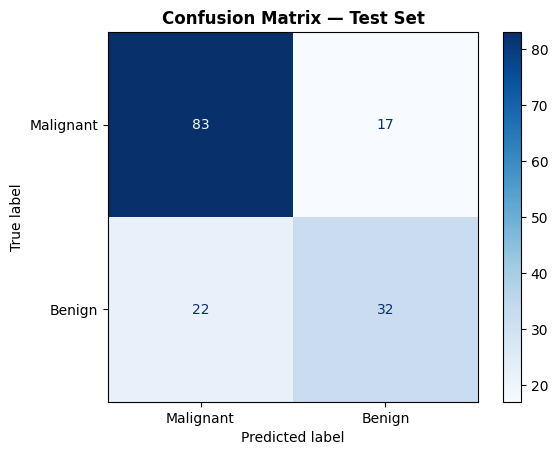

Correctly identified diabetes : 32
Correctly identified no  diabetes    : 83
Missed diabetes (False Negative): 22 - the most dangerous error in medicine
False alarms   (False Positive): 17


In [29]:
y_pred = best_model.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)

print("=" * 40)
print("  FINAL TEST ACCURACY")
print("=" * 40)
print(f"  {test_acc*100:.2f}%")
print("=" * 40)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Malignant', 'Benign']).plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set', fontweight='bold')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Correctly identified diabetes : {tp}")
print(f"Correctly identified no  diabetes    : {tn}")
print(f"Missed diabetes (False Negative): {fn} - the most dangerous error in medicine")
print(f"False alarms   (False Positive): {fp}")

---
## Step 8 — Final Reflection

Answer in 3–5 sentences:
- How did your model perform?
- What does the confusion matrix tell you?
- What would be the consequence of a high number of False Negatives in a real clinical setting?

*Write your answer here.*

---
*AIxMed26 — Session 1 Assignment*